In [1]:
# Import required libraries
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Create synthetic dataset
np.random.seed(42)
data = {
    'mileage': np.random.randint(5000, 200000, 100),
    'age': np.random.randint(1, 15, 100),
    'engine_size': np.random.uniform(1.0, 5.0, 100),
    'price': np.random.randint(5000, 35000, 100)
}

df = pd.DataFrame(data)

# Features and target
X = df[['mileage', 'age', 'engine_size']]
y = df['price']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear, Ridge, and Lasso models
lr = LinearRegression().fit(X_train, y_train)
ridge = Ridge(alpha=10).fit(X_train, y_train)
lasso = Lasso(alpha=1000).fit(X_train, y_train)  # Higher alpha for visible effect

# Predict
y_pred_lr = lr.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

# Print coefficients
print("Linear Regression Coefficients:", lr.coef_)
print("Ridge Regression Coefficients:", ridge.coef_)
print("Lasso Regression Coefficients:", lasso.coef_)

# Compare errors
print("\nMean Squared Error (Linear):", mean_squared_error(y_test, y_pred_lr))
print("Mean Squared Error (Ridge):", mean_squared_error(y_test, y_pred_ridge))
print("Mean Squared Error (Lasso):", mean_squared_error(y_test, y_pred_lasso))


Linear Regression Coefficients: [-1.01175138e-02 -2.39780793e+02 -7.67238171e+01]
Ridge Regression Coefficients: [-1.01206927e-02 -2.37884574e+02 -6.93726770e+01]
Lasso Regression Coefficients: [-1.02567080e-02 -1.76441907e+02 -0.00000000e+00]

Mean Squared Error (Linear): 42176900.03371321
Mean Squared Error (Ridge): 42144598.59207954
Mean Squared Error (Lasso): 41668946.14224987


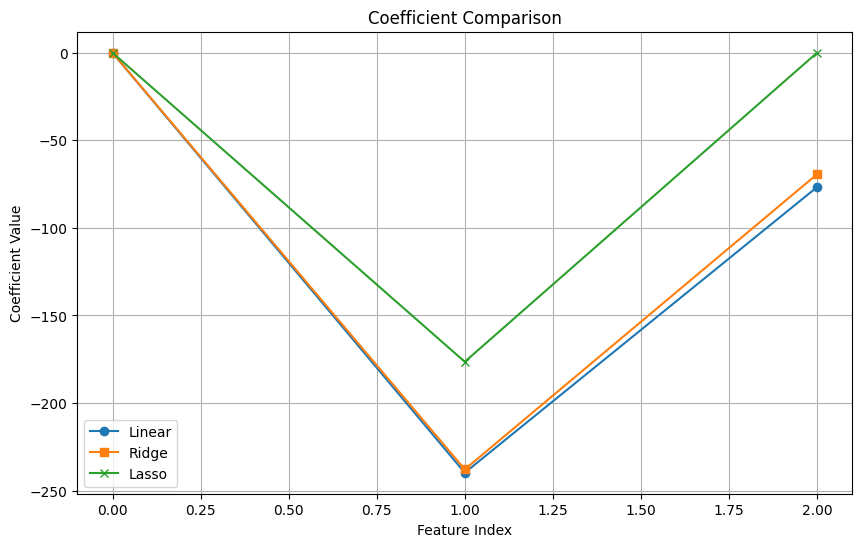

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(lr.coef_, label='Linear', marker='o')
plt.plot(ridge.coef_, label='Ridge', marker='s')
plt.plot(lasso.coef_, label='Lasso', marker='x')
plt.title("Coefficient Comparison")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.legend()
plt.grid(True)
plt.show()


In [4]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Load sample data
X, y = load_diabetes(return_X_y=True)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Linear Regression (no regularization)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Ridge Regression (L2)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

# Lasso Regression (L1)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

# Compare MSE
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))
print("Ridge Regression MSE:", mean_squared_error(y_test, y_pred_ridge))
print("Lasso Regression MSE:", mean_squared_error(y_test, y_pred_lasso))


Linear Regression MSE: 2900.19362849348
Ridge Regression MSE: 3077.41593882723
Lasso Regression MSE: 2798.193485169719


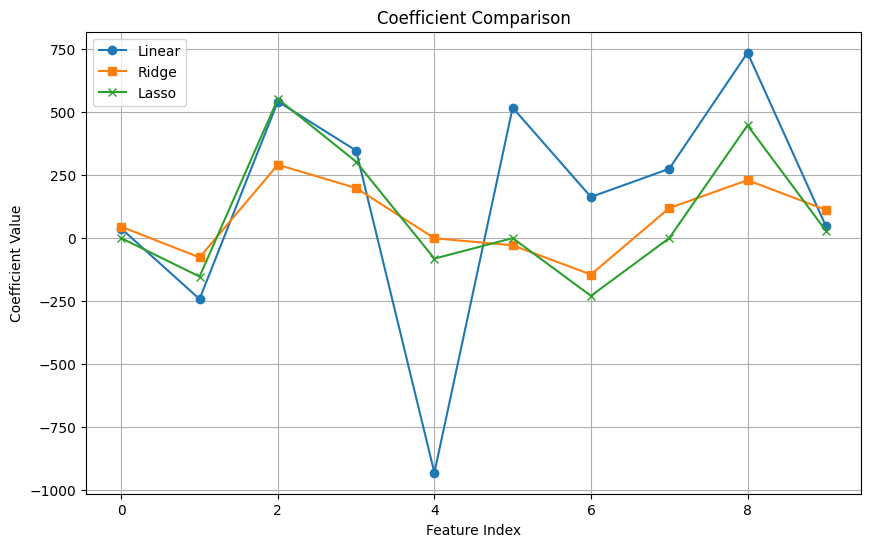

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(lr.coef_, label='Linear', marker='o')
plt.plot(ridge.coef_, label='Ridge', marker='s')
plt.plot(lasso.coef_, label='Lasso', marker='x')
plt.title("Coefficient Comparison")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.legend()
plt.grid(True)
plt.show()


In [7]:
# Try different values of alpha for Ridge and Lasso
for a in [0.01, 0.1, 1.0, 10]:
    model = Lasso(alpha=a)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Lasso alpha={a}: MSE = {mean_squared_error(y_test, y_pred)}")


Lasso alpha=0.01: MSE = 2878.559386186607
Lasso alpha=0.1: MSE = 2798.193485169719
Lasso alpha=1.0: MSE = 3403.5757216070733
Lasso alpha=10: MSE = 5361.533457238513


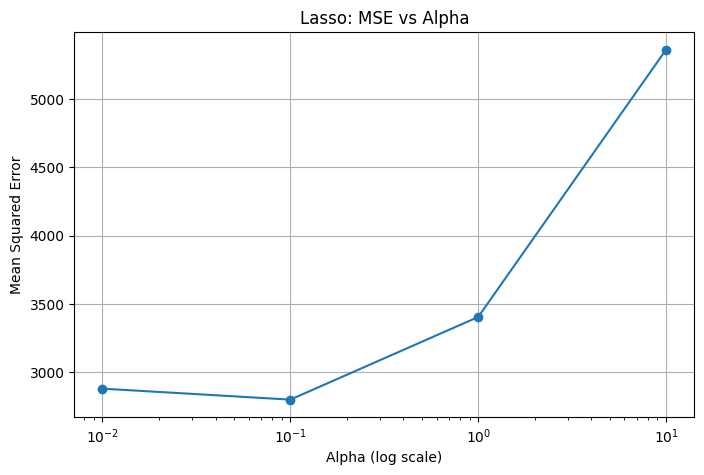

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

alphas = [0.01, 0.1, 1.0, 10]
mse_scores = []

for a in alphas:
    model = Lasso(alpha=a)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse_scores.append(mean_squared_error(y_test, y_pred))

plt.figure(figsize=(8,5))
plt.plot(alphas, mse_scores, marker='o')
plt.xscale('log')  # Lasso alphas are better on a log scale
plt.title("Lasso: MSE vs Alpha")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Mean Squared Error")
plt.grid(True)
plt.show()
